# day 37

## hitherto

Just as a guide to this, I changed a few things after the lecture to help make some more sense out of this. Hopefully you can see the places below were you should change some things and play around with this.

## herein

We first will talk about oscillatory motion. We know how to solve simple problems along these lines with the differential equation solving that we have done, and we can perhaps look at a slightly more complicated example. But we can also see something in the solutions to these differential equations. That the motion is oscillatory: it is either modeled with a sine or cosine (or both!). This means that the behavior of all such systems will act like a series of sines and cosines. So if we assume that going in then we can assemble solutions to complicated motion by first finding the underlying sine behavior and then adding them up. This is in essence what we are doing when we find the *eigenvalues* and *eigenvectors* of a oscillatory system. Finding these values is as simple as calling the `np.linalg.eig` function, so this is more about how we construct the matrices and how we interpret the values it spits out more than anything.




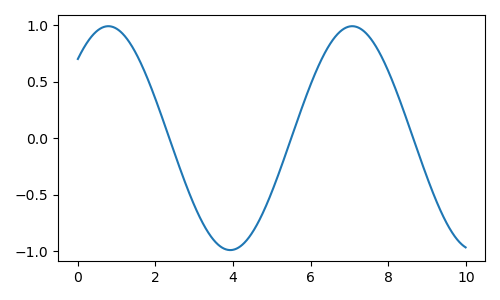

In [21]:
# define the differential equation
def f(r_, t_): # don't forget r is a vector!
    x = r_[0]
    v = r_[1]
    m = 1 # kg
    k = 1 # N/m
    fx = v  # this is the dx/dt equation!
    fv = -k/m*x
    return(np.array([fx, fv]))

# define the boundary condition
a = 0.0
b = 10
N = 1000
dt = (b-a)/N

# Runge-Kutta 4th order

####### play around with these initial conditions!! ##### 
r = np.array([0.70, 0.70]) 
#########################################################

tpoints = np.arange(a, b, dt)

xpoints = []
vpoints = []

for i in tpoints:
    xpoints.append(r[0])
    vpoints.append(r[1])
    k1 = dt*f(r, i)
    k2 = dt*f(r+1/2*k1, i+1/2*dt)
    k3 = dt*f(r+1/2*k2, i+1/2*dt)
    k4 = dt*f(r+k3, i+dt)
    r = r + (k1+2*k2+2*k3+k4)/6

fig0, ax0 = plt.subplots(figsize=(5,3))
ax0.plot(tpoints, xpoints)
fig0.tight_layout()
#ax0.plot(tpoints, xpointsD)
#ax0.plot(tpointsD2, vpointsD2)

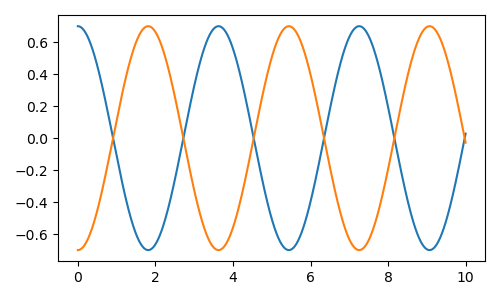

In [24]:
# define the differential equation
def f(r_, t_): # don't forget r is a vector!
    x1, x2, v1, v2 = r_
    m = 1 # kg
    k = 1 # N/m
    fx1 = v1  # this is the dx/dt equation!
    fx2 = v2
    fv1 = -k/m*x1+k/m*(x2-x1)
    fv2 = -k/m*x2-k/m*(x2-x1)
    return(np.array([fx1, fx2, fv1, fv2]))

# define the boundary condition
a = 0.0
b = 10
N = 10000
dt = (b-a)/N

# Runge-Kutta 4th order

####### play around with these initial conditions!! ##### 
r = np.array([0.70, -0.70, 0, 0]) 
# r = np.array([0.70, 0.0, 0, 0]) 
#########################################################

tpoints = np.arange(a, b, dt)

xpoints1 = []
xpoints2 = []
vpoints1 = []
vpoints2 = []

for i in tpoints:
    xpoints1.append(r[0])
    xpoints2.append(r[1])
    vpoints1.append(r[2])
    vpoints2.append(r[3])    
    k1 = dt*f(r, i)
    k2 = dt*f(r+1/2*k1, i+1/2*dt)
    k3 = dt*f(r+1/2*k2, i+1/2*dt)
    k4 = dt*f(r+k3, i+dt)
    r = r + (k1+2*k2+2*k3+k4)/6

fig1, ax1 = plt.subplots(figsize=(5,3))
ax1.plot(tpoints, xpoints1)
ax1.plot(tpoints, xpoints2)
fig1.tight_layout()


In [5]:
K = np.matrix([[2, -1],[-1,2]])
K

matrix([[ 2, -1],
        [-1,  2]])

In [7]:
values, vectors = np.linalg.eig(K)

In [8]:
values

array([3., 1.])

In [9]:
vectors

matrix([[ 0.70710678,  0.70710678],
        [-0.70710678,  0.70710678]])